In [17]:
from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import MarkdownHeaderTextSplitter
from loguru import logger
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [18]:
ROOT_PATH = Path.cwd().parent
RAW_DATA_PATH = ROOT_PATH / "data" / "raw"
REPORT_PATH = ROOT_PATH / "reports"

In [19]:
HEADERS_TO_SPLIT_ON = [
    ("#", "Entity"),
    ("##", "Section")
]

EXPLICIT_NULL_STRINGS = [
    "wip",
    "tbd",
    "to be determined",
    "information not yet provided",
    "none",
    "n/a"
]

In [20]:
def is_chunk_missing(content: str) -> bool:
    """Evaluates if a chunk represents missing/empty data."""
    # 1. Check if it's completely empty
    # 2. Check if it matches any of our Explicit Null phrases
    cleaned_text = content.strip().lower()

    if not cleaned_text:
        return True

    for null_str in EXPLICIT_NULL_STRINGS:
        if null_str in cleaned_text and len(cleaned_text) < 50:
            return True

    return False

In [21]:
def analyze_sparsity() -> pd.DataFrame:
    """Chunks documents and calculates missingness per section."""
    logger.info("Initializing Sparsity Analysis...")
    markdown_splitter = MarkdownHeaderTextSplitter(headers_to_split_on=HEADERS_TO_SPLIT_ON)
    md_files = list(RAW_DATA_PATH.glob("*.[mM][dD]"))

    if not md_files:
        logger.error(f"Could not find any Markdown files in {RAW_DATA_PATH.resolve()}")
        return pd.DataFrame()

    chunk_data = []

    for file_path in md_files:
        try:
            loader = TextLoader(str(file_path), encoding="utf-8")
            raw_text = loader.load()[0].page_content
            chunks = markdown_splitter.split_text(raw_text)

            for chunk in chunks:
                section_name = chunk.metadata.get("Section", "Intro/Floating Text")
                is_missing = is_chunk_missing(chunk.page_content)

                chunk_data.append({
                    "Section": section_name,
                    "IsMissing": is_missing
                })
        except Exception as e:
            logger.error(f"Failed to process {file_path.name}: {e}")

    df = pd.DataFrame(chunk_data)

    if df.empty:
        logger.error("Dataframe is empty. No chunks extracted.")
        return df

    sparsity_df = df.groupby("Section").agg(
        Total_Chunks=('IsMissing', 'count'),
        Missing_Count=('IsMissing', 'sum')
    )

    sparsity_df['Completeness_%'] = ((1 - (sparsity_df['Missing_Count'] / sparsity_df['Total_Chunks'])) * 100).round(2)
    sparsity_df['Missing_%'] = ((sparsity_df['Missing_Count'] / sparsity_df['Total_Chunks']) * 100).round(2)

    return sparsity_df.sort_values(by="Missing_%", ascending=False)

In [22]:
def generate_sparsity_report(df: pd.DataFrame):
    """Outputs the table and plots the completeness chart."""
    print("Sparsity analysis: Missing data by section")
    print(df.to_string())

    logger.info("Rendering Completeness Bar Chart.")

    plot_df = df[df.index != "Intro/Floating Text"].reset_index()

    plt.figure(figsize=(12, 7))

    ax = sns.barplot(x="Completeness_%",
                     y="Section",
                     data=plot_df,
                     legend=False)

    plt.title("Data Completeness Rate by Document Section", fontsize=16, pad=20)
    plt.xlabel("Completeness Percentage (%)", fontsize=12)
    plt.ylabel("Document Section", fontsize=12)
    plt.axvline(x=100,
                color='green',
                linestyle='-',
                alpha=0.3)

    for i, v in enumerate(plot_df["Completeness_%"]):
        ax.text(v + 1, i + 0.1, f"{v}%", color='black', fontweight='bold', fontsize=10)

    plt.xlim(0, 110)
    plt.tight_layout()
    plot_path = "sparsity_analysis.pdf"
    plt.savefig(REPORT_PATH / plot_path, format='pdf')
    logger.success(f"Plot saved successfully as '{plot_path}'!")

In [23]:
df_sparsity = analyze_sparsity()

2026-03-10 07:42:13.325 | INFO     | __main__:analyze_sparsity:3 - Initializing Sparsity Analysis...


2026-03-10 07:42:13.452 | INFO     | __main__:generate_sparsity_report:6 - Rendering Completeness Bar Chart.
2026-03-10 07:42:13.616 | SUCCESS  | __main__:generate_sparsity_report:32 - Plot saved successfully as 'sparsity_analysis.pdf'!


Sparsity analysis: Missing data by section
                                                                    Total_Chunks  Missing_Count  Completeness_%  Missing_%
Section                                                                                                                   
Constructive questions                                                        56             39           30.36      69.64
CLOs-PLOs maps                                                                56             13           76.79      23.21
Sessions                                                                      56              2           96.43       3.57
Materials                                                                     56              1           98.21       1.79
Learning outcomes                                                             56              1           98.21       1.79
Assignments and assessments                                                   56              1 

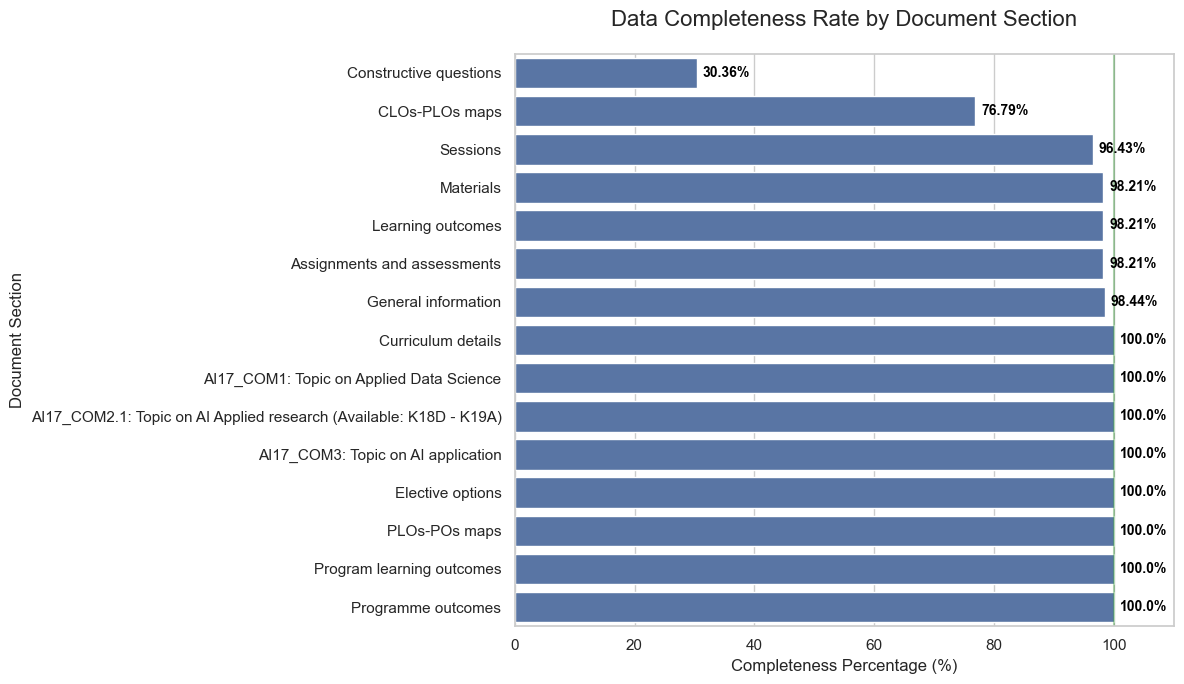

In [24]:
generate_sparsity_report(df_sparsity)